In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [8]:
titanic=sns.load_dataset("titanic")

feature=["pclass","sex","fare","embarked","age"]
target=["survived"]

#handle missing data
imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

#encode
le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

X=titanic[feature]
y=titanic["survived"]

#train_test-split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)


In [18]:
#Decision tree
model=DecisionTreeClassifier(max_depth=4)

model.fit(X_train,y_train)

y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

print("Training Accuracy:",accuracy_score(y_train,y_pred_train)*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred_test)*100,"%")

#classics case of overfitting

Training Accuracy: 84.75120385232745 %
Testing Accuracy: 82.46268656716418 %


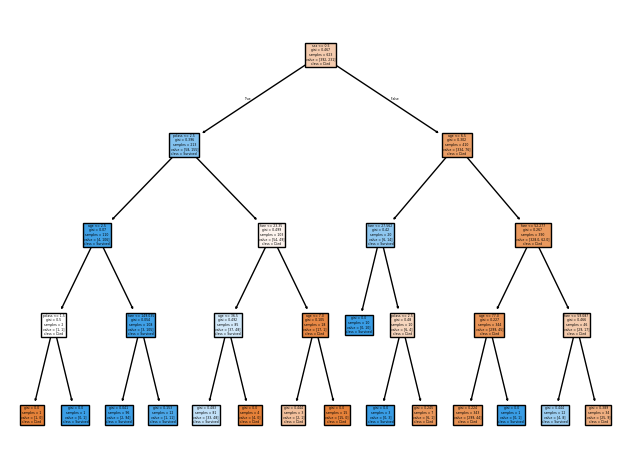

In [19]:
from sklearn.tree import plot_tree

plt.Figure(figsize=(18,10))
plot_tree(model,feature_names=X.columns,class_names=['Died','Survived'],filled=True)

plt.tight_layout()

In [20]:
#rRandome Forest
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=501,oob_score=True)

rf.fit(X_train,y_train)

y_pred=rf.predict(X_test)

print("oob score:",rf.oob_score_*100,"%")
print("training accuracy_score:",accuracy_score(y_test,y_pred)*100,"%")

oob score: 81.54093097913324 %
training accuracy_score: 77.61194029850746 %


In [21]:
#Bagging Classifier

from sklearn.ensemble import BaggingClassifier

base_model=DecisionTreeClassifier()

bagging=BaggingClassifier(
    base_model,n_estimators=201
)

model.fit(X_train,y_train)

y_pred_test=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.7761194029850746
